# Trabalho Final - Inteligência Computacional

Este notebook contém o desenvolvimento dos experimentos de regressão e classificação multiclasse conforme as instruções do trabalho final da disciplina. A estrutura segue as etapas recomendadas para garantir reprodutibilidade, análise crítica e apresentação dos resultados.

## Sumário
1. Importação de Bibliotecas
2. Carregamento e Análise Exploratória dos Dados
3. Pré-processamento dos Dados
4. Experimento 1 - Regressão
5. Experimento 2 - Classificação Multiclasse
6. Análise Comparativa dos Resultados
7. Análise Crítica dos Algoritmos


In [14]:
# Importação de Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score, confusion_matrix, roc_auc_score, cohen_kappa_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.neural_network import MLPRegressor, MLPClassifier
import warnings
warnings.filterwarnings('ignore')

## Carregamento e Análise Exploratória dos Dados

Nesta seção, serão carregados os datasets obrigatórios (Energy Efficiency e Wine Quality Red) e um dataset de livre escolha. Serão realizadas análises exploratórias, estatísticas descritivas e visualizações para identificar características relevantes dos dados.

In [15]:
# Carregamento dos Dados a partir da pasta 'dataset'

import pandas as pd

# Caminhos locais dos arquivos já baixados
energy_path = 'dataset/ENB2012_data.xlsx'
wine_path = 'dataset/winequality-red.csv'
iris_path = 'dataset/iris.data'

# Carregamento dos dados
df_energy = pd.read_excel(energy_path)
df_wine = pd.read_csv(wine_path, sep=';')
iris_columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df_iris = pd.read_csv(iris_path, names=iris_columns)

Energy Efficiency Dataset:
               X1          X2          X3          X4         X5          X6  \
count  768.000000  768.000000  768.000000  768.000000  768.00000  768.000000   
mean     0.764167  671.708333  318.500000  176.604167    5.25000    3.500000   
std      0.105777   88.086116   43.626481   45.165950    1.75114    1.118763   
min      0.620000  514.500000  245.000000  110.250000    3.50000    2.000000   
25%      0.682500  606.375000  294.000000  140.875000    3.50000    2.750000   
50%      0.750000  673.750000  318.500000  183.750000    5.25000    3.500000   
75%      0.830000  741.125000  343.000000  220.500000    7.00000    4.250000   
max      0.980000  808.500000  416.500000  220.500000    7.00000    5.000000   

               X7         X8          Y1          Y2  
count  768.000000  768.00000  768.000000  768.000000  
mean     0.234375    2.81250   22.307195   24.587760  
std      0.133221    1.55096   10.090204    9.513306  
min      0.000000    0.00000    

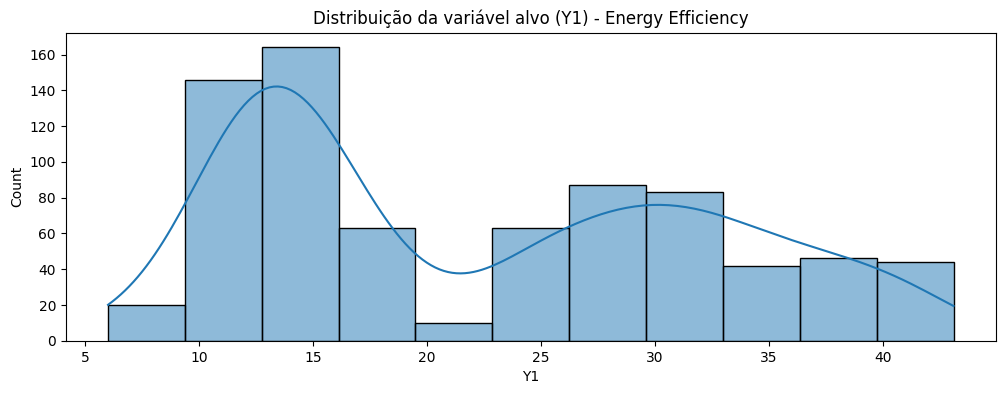

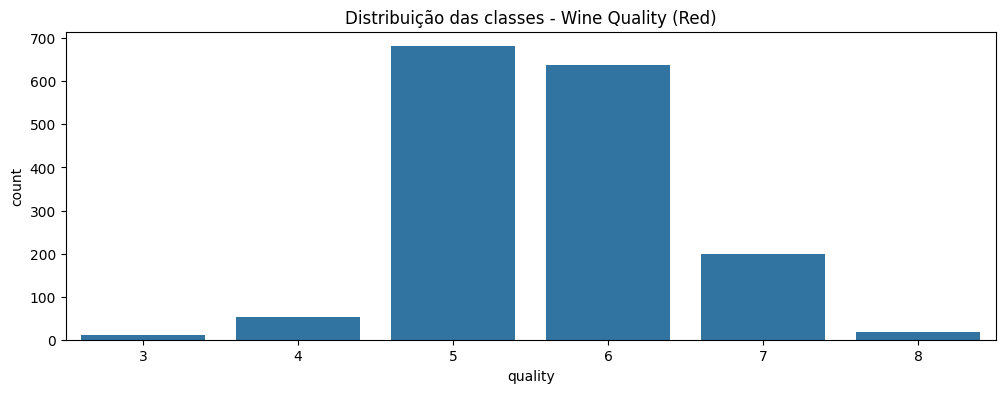

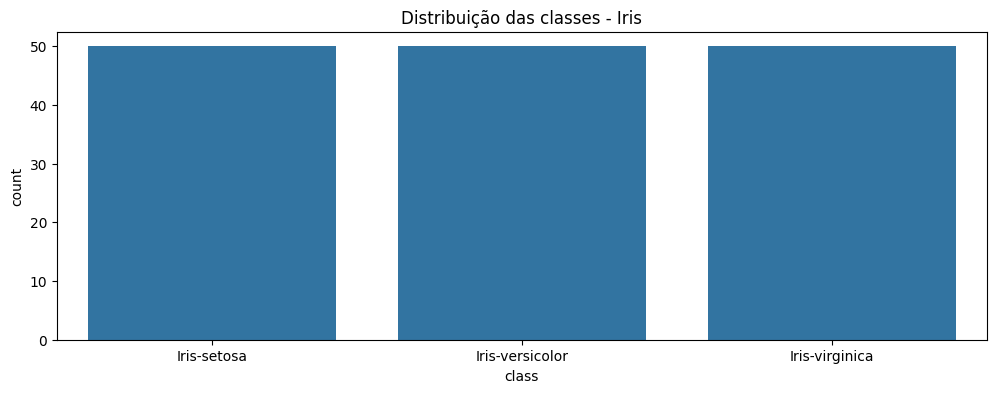

In [16]:
# Análise Exploratória
# Estatísticas descritivas
print('Energy Efficiency Dataset:')
print(df_energy.describe())
print('\nWine Quality Dataset (Red):')
print(df_wine.describe())
print('\nIris Dataset:')
print(df_iris.describe())

# Visualização de distribuições
plt.figure(figsize=(12, 4))
sns.histplot(df_energy['Y1'], kde=True)
plt.title('Distribuição da variável alvo (Y1) - Energy Efficiency')
plt.show()

plt.figure(figsize=(12, 4))
sns.countplot(x='quality', data=df_wine)
plt.title('Distribuição das classes - Wine Quality (Red)')
plt.show()

plt.figure(figsize=(12, 4))
sns.countplot(x='class', data=df_iris)
plt.title('Distribuição das classes - Iris')
plt.show()

## Pré-processamento dos Dados

Nesta etapa, serão aplicadas técnicas de pré-processamento como normalização, tratamento de valores ausentes, codificação de variáveis categóricas e divisão dos dados em treino e teste conforme especificado para cada experimento.

In [17]:
# Pré-processamento
# Energy Efficiency Dataset
energy_features = df_energy.columns[:8]
energy_target = 'Y1'
X_energy = df_energy[energy_features]
y_energy = df_energy[energy_target]
scaler_energy = StandardScaler()
X_energy_scaled = scaler_energy.fit_transform(X_energy)
X_train_energy, X_test_energy, y_train_energy, y_test_energy = train_test_split(X_energy_scaled, y_energy, test_size=0.3, random_state=42)

# Wine Quality Dataset (Red)
wine_features = df_wine.columns[:-1]
wine_target = 'quality'
X_wine = df_wine[wine_features]
y_wine = df_wine[wine_target]
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(X_wine_scaled, y_wine, test_size=0.2, random_state=42)

# Iris Dataset
iris_features = df_iris.columns[:-1]
iris_target = 'class'
X_iris = df_iris[iris_features]
y_iris = LabelEncoder().fit_transform(df_iris[iris_target])
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris_scaled, y_iris, test_size=0.2, random_state=42)

## Experimento 1 - Regressão

Nesta seção, serão implementadas e testadas pelo menos 4 técnicas de regressão nos datasets Energy Efficiency e de livre escolha. Serão calculadas as métricas RMSE (obrigatória), MAE, R² e realizadas 30 repetições para algoritmos estocásticos.

In [18]:
# Modelos de Regressão
regressors = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(),
    'MLPRegressor': MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
}

results_energy = {name: [] for name in regressors}
seeds = range(1, 31)
for name, model in regressors.items():
    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(X_energy_scaled, y_energy, test_size=0.3, random_state=seed)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmse = mean_squared_error(y_test, y_pred) ** 0.5  # Corrigido para calcular RMSE manualmente
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results_energy[name].append({'RMSE': rmse, 'MAE': mae, 'R2': r2})

# Exemplo de visualização dos resultados
import pandas as pd
energy_summary = {}
for name in regressors:
    df = pd.DataFrame(results_energy[name])
    energy_summary[name] = df.mean().to_dict()
pd.DataFrame(energy_summary).T

,RMSE,MAE,R2
LinearRegression,2.970777,2.109132,0.912785
RandomForestRegressor,0.517490,0.345165,0.997314
SVR,2.828952,1.902756,0.920956
MLPRegressor,2.661150,1.871310,0.929896


In [19]:
# Regressão no dataset livre (Iris - exemplo usando petal_length como alvo)
X_iris_reg = df_iris[iris_features]
y_iris_reg = df_iris['petal_length']
X_iris_reg_scaled = scaler_iris.fit_transform(X_iris_reg)

results_iris = {name: [] for name in regressors}
for name, model in regressors.items():
    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(X_iris_reg_scaled, y_iris_reg, test_size=0.2, random_state=seed)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmse = mean_squared_error(y_test, y_pred) ** 0.5  # Corrigido para calcular RMSE manualmente
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results_iris[name].append({'RMSE': rmse, 'MAE': mae, 'R2': r2})

iris_summary = {}
for name in regressors:
    df = pd.DataFrame(results_iris[name])
    iris_summary[name] = df.mean().to_dict()
pd.DataFrame(iris_summary).T

,RMSE,MAE,R2
LinearRegression,1.028616e-15,8.218118e-16,1.000000
RandomForestRegressor,6.152031e-02,2.933333e-02,0.998418
SVR,1.868689e-01,1.105059e-01,0.986875
MLPRegressor,3.265877e-01,2.605372e-01,0.961721


## Experimento 2 - Classificação Multiclasse

Nesta seção, serão implementados algoritmos de classificação nos datasets Wine Quality (Red) e de livre escolha. Serão calculadas as métricas acurácia, F1-score e outras opcionais, com 30 repetições utilizando sementes de 1 a 30.

In [20]:
# Modelos de Classificação
classifiers = {
    'LogisticRegression': LogisticRegression(max_iter=500, random_state=42),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVC': SVC(),
    'MLPClassifier': MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
}

results_wine = {name: [] for name in classifiers}
for name, model in classifiers.items():
    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(X_wine_scaled, y_wine, test_size=0.2, random_state=seed)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        kappa = cohen_kappa_score(y_test, y_pred)
        results_wine[name].append({'Acuracia': acc, 'F1': f1, 'Kappa': kappa})

wine_summary = {}
for name in classifiers:
    df = pd.DataFrame(results_wine[name])
    wine_summary[name] = df.mean().to_dict()
pd.DataFrame(wine_summary).T

,Acuracia,F1,Kappa
LogisticRegression,0.596042,0.576052,0.335257
RandomForestClassifier,0.697292,0.679907,0.506306
SVC,0.628125,0.604313,0.382403
MLPClassifier,0.618542,0.607899,0.388191


In [21]:
# Classificação no dataset livre (Iris)
results_iris_cls = {name: [] for name in classifiers}
for name, model in classifiers.items():
    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(X_iris_scaled, y_iris, test_size=0.2, random_state=seed)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        kappa = cohen_kappa_score(y_test, y_pred)
        results_iris_cls[name].append({'Acuracia': acc, 'F1': f1, 'Kappa': kappa})

iris_cls_summary = {}
for name in classifiers:
    df = pd.DataFrame(results_iris_cls[name])
    iris_cls_summary[name] = df.mean().to_dict()
pd.DataFrame(iris_cls_summary).T

,Acuracia,F1,Kappa
LogisticRegression,0.948889,0.948866,0.921459
RandomForestClassifier,0.945556,0.945397,0.916290
SVC,0.955556,0.955559,0.931062
MLPClassifier,0.944444,0.944691,0.913996


## Análise Comparativa dos Resultados

Nesta seção, os resultados dos experimentos serão comparados utilizando testes estatísticos, gráficos de boxplot e tabelas. Serão analisadas médias, desvios padrão e significância estatística entre os algoritmos.

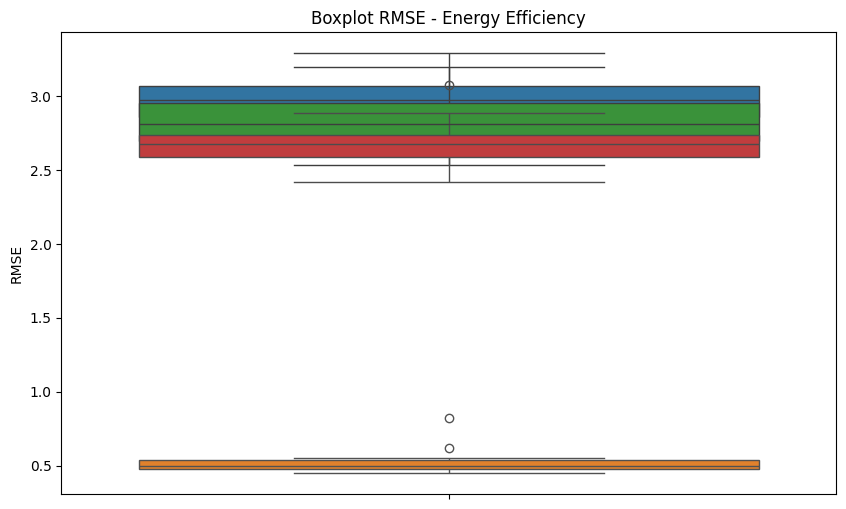

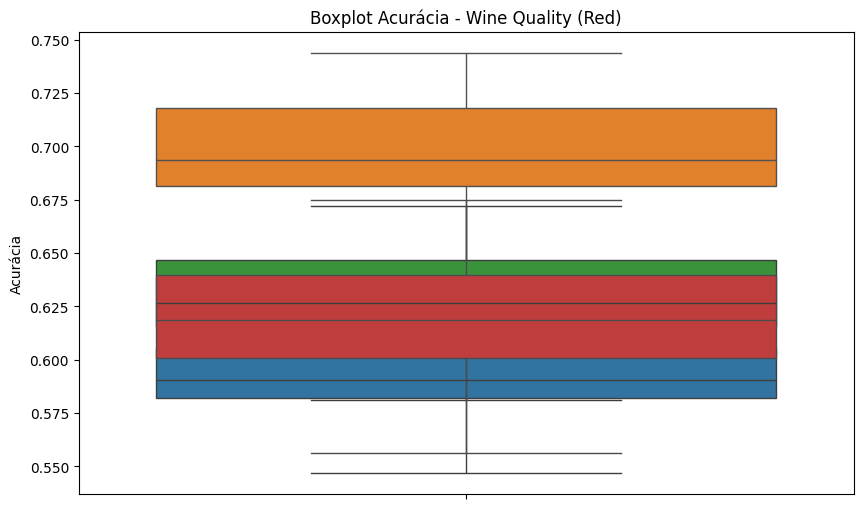

In [22]:
# Boxplot dos resultados de regressão (Energy Efficiency)
plt.figure(figsize=(10, 6))
for name in regressors:
    df = pd.DataFrame(results_energy[name])
    sns.boxplot(data=df['RMSE'], label=name)
plt.title('Boxplot RMSE - Energy Efficiency')
plt.ylabel('RMSE')
plt.show()

# Boxplot dos resultados de classificação (Wine Quality)
plt.figure(figsize=(10, 6))
for name in classifiers:
    df = pd.DataFrame(results_wine[name])
    sns.boxplot(data=df['Acuracia'], label=name)
plt.title('Boxplot Acurácia - Wine Quality (Red)')
plt.ylabel('Acurácia')
plt.show()

## Análise Crítica dos Algoritmos

Nesta seção, será realizada uma avaliação crítica dos algoritmos utilizados, considerando desempenho, robustez, interpretabilidade, complexidade computacional e adequação aos problemas propostos.